
Phân loại nợ 5 nhóm theo TT11/2021 SBV | NPL ratio < 3%: tốt | 3-5%: theo dõi | > 5%: cảnh báo


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Kết nối DuckDB → PostgreSQL ───────────────────────────────────────────────
PG = "dbname=risk_banking user=namphuong password=2104 host=localhost port=5432"
conn = duckdb.connect()
conn.execute("INSTALL postgres_scanner; LOAD postgres_scanner;")
conn.execute(f"ATTACH '{PG}' AS pg (TYPE postgres);")

# ── Style cho chart ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})
COLORS = {
    "navy":   "#1D4E89", "blue":  "#2E86AB",
    "teal":   "#1D9E75", "green": "#27AE60",
    "amber":  "#E67E22", "red":   "#C0392B",
    "purple": "#8E44AD", "gray":  "#5D6D7E",
}
print("✓ Kết nối thành công — sẵn sàng phân tích")

✓ Kết nối thành công — sẵn sàng phân tích


## 1.1 — NPL Ratio theo tháng

In [2]:
df_npl = conn.execute("""
    SELECT
        issue_month,
        COUNT(*)                                             AS total_loans,
        SUM(CASE WHEN debt_group >= 3 THEN 1 ELSE 0 END)    AS npl_count,
        ROUND(100.0 * SUM(CASE WHEN debt_group >= 3
            THEN 1 ELSE 0 END) / COUNT(*), 4)               AS npl_ratio_pct,
        ROUND(100.0 * SUM(CASE WHEN debt_group = 1
            THEN 1 ELSE 0 END) / COUNT(*), 2)               AS pct_group1,
        ROUND(100.0 * SUM(CASE WHEN debt_group = 2
            THEN 1 ELSE 0 END) / COUNT(*), 2)               AS pct_group2,
        ROUND(100.0 * SUM(CASE WHEN debt_group = 3
            THEN 1 ELSE 0 END) / COUNT(*), 2)               AS pct_group3,
        ROUND(100.0 * SUM(CASE WHEN debt_group = 4
            THEN 1 ELSE 0 END) / COUNT(*), 2)               AS pct_group4,
        ROUND(100.0 * SUM(CASE WHEN debt_group = 5
            THEN 1 ELSE 0 END) / COUNT(*), 2)               AS pct_group5,
        ROUND(AVG(fico_range_low), 2)                        AS avg_fico,
        ROUND(AVG(int_rate), 4)                              AS avg_int_rate
    FROM pg.accepted_loans
    WHERE issue_month IS NOT NULL
    GROUP BY issue_month
    ORDER BY issue_month
""").df()

print(f"Tổng số tháng: {len(df_npl)}")
print(f"NPL ratio trung bình: {df_npl.npl_ratio_pct.mean():.2f}%")
print(f"NPL ratio cao nhất:   {df_npl.npl_ratio_pct.max():.2f}% tháng {df_npl.loc[df_npl.npl_ratio_pct.idxmax(), 'issue_month']}")
df_npl.head(10)


Tổng số tháng: 140
NPL ratio trung bình: 12.84%
NPL ratio cao nhất:   19.07% tháng 2015-03


,issue_month,total_loans,npl_count,npl_ratio_pct,pct_group1,pct_group2,pct_group3,pct_group4,pct_group5,avg_fico,avg_int_rate
0,2007-06,24,0.0,0.0000,100.00,0.0,0.0,0.0,0.00,712.92,9.8146
1,2007-07,63,0.0,0.0000,100.00,0.0,0.0,0.0,0.00,700.08,11.1586
2,2007-08,74,7.0,9.4595,90.54,0.0,0.0,0.0,9.46,699.32,11.5435
3,2007-09,53,3.0,5.6604,94.34,0.0,0.0,0.0,5.66,684.25,12.4632
4,2007-10,105,10.0,9.5238,90.48,0.0,0.0,0.0,9.52,683.86,12.4385
5,2007-11,112,7.0,6.2500,93.75,0.0,0.0,0.0,6.25,683.39,11.9623
6,2007-12,172,18.0,10.4651,89.53,0.0,0.0,0.0,10.47,688.81,11.8105
7,2008-01,305,31.0,10.1639,89.84,0.0,0.0,0.0,10.16,694.20,11.7204
8,2008-02,306,25.0,8.1699,91.83,0.0,0.0,0.0,8.17,696.03,12.1959
9,2008-03,402,40.0,9.9502,90.05,0.0,0.0,0.0,9.95,691.94,12.3058


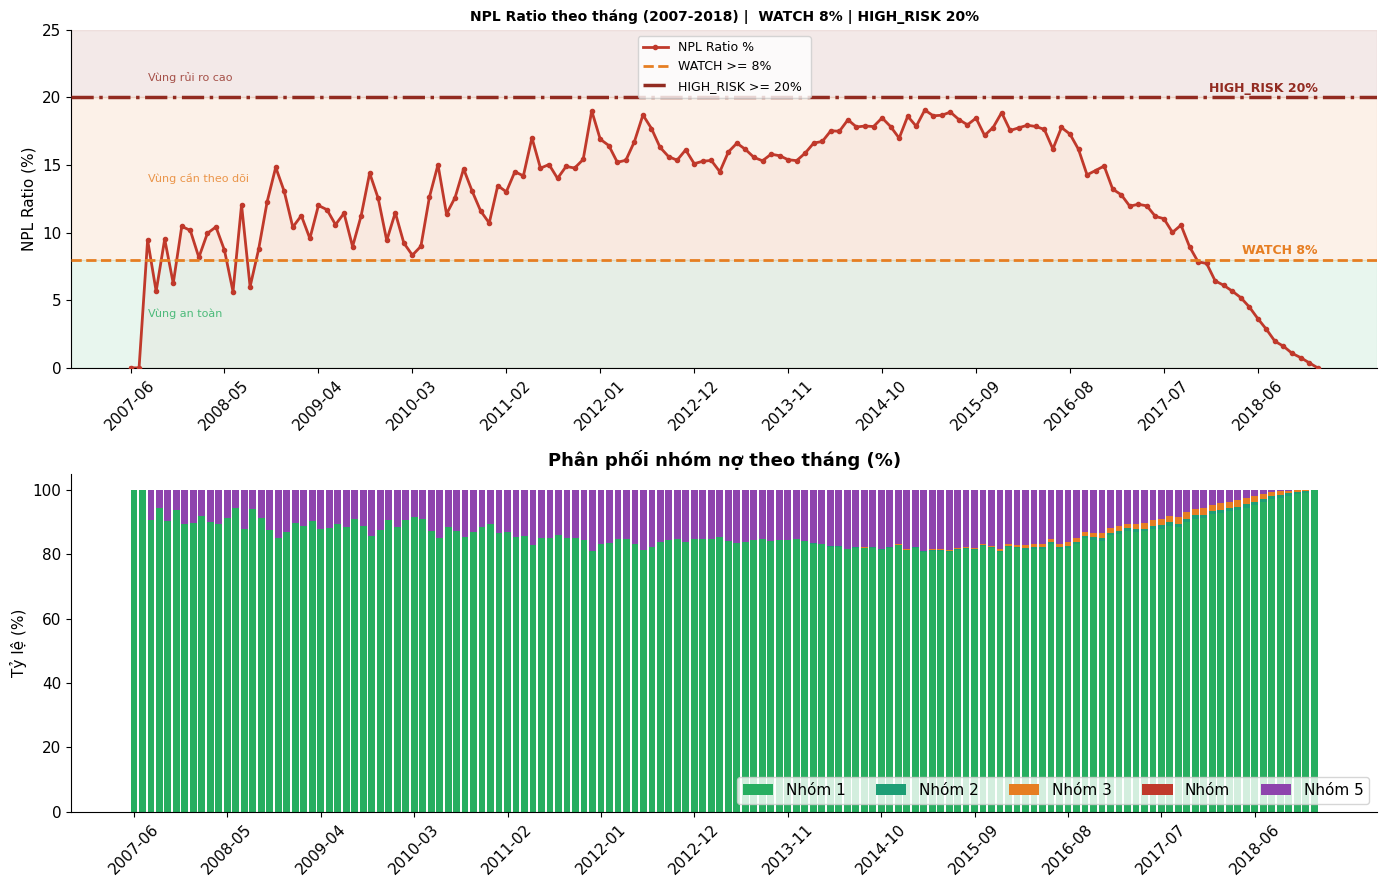

In [16]:
NPL_WATCH     = 8.0
NPL_HIGH_RISK = 20.0

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Chart 1: NPL trend ───────────────────────────────────────────────────────
ax1 = axes[0]
xs_month = df_npl["issue_month"]

# Vung nen phan tang rui ro
ax1.axhspan(0,             NPL_WATCH,     alpha=0.10, color="#27AE60", zorder=0)
ax1.axhspan(NPL_WATCH,     NPL_HIGH_RISK, alpha=0.10, color="#E67E22", zorder=0)
ax1.axhspan(NPL_HIGH_RISK, 25,            alpha=0.10, color="#922B21", zorder=0)

# Duong NPL
ax1.plot(xs_month, df_npl["npl_ratio_pct"],
         color=COLORS["red"], linewidth=2, marker="o", markersize=3,
         label="NPL Ratio %", zorder=3)
ax1.fill_between(xs_month, df_npl["npl_ratio_pct"],
                 alpha=0.04, color=COLORS["red"], zorder=2)

# consumer lending standard
ax1.axhline(NPL_WATCH,     color="#E67E22", linestyle="--", linewidth=2.0,
            label="WATCH >= 8% ", zorder=4)
ax1.axhline(NPL_HIGH_RISK, color="#922B21", linestyle="-.", linewidth=2.5,
            label="HIGH_RISK >= 20% ", zorder=4)

# Nhan nguong ben phai
ax1.text(xs_month.iloc[-1], NPL_WATCH + 0.4,
         "WATCH 8%", fontsize=9, color="#E67E22", ha="right", fontweight="bold")
ax1.text(xs_month.iloc[-1], NPL_HIGH_RISK + 0.4,
         "HIGH_RISK 20%", fontsize=9, color="#922B21", ha="right", fontweight="bold")

# Label vung rui ro
ax1.text(xs_month.iloc[2], NPL_WATCH / 2,
         "Vùng an toàn", fontsize=8, color="#27AE60", alpha=0.8, va="center")
ax1.text(xs_month.iloc[2], (NPL_WATCH + NPL_HIGH_RISK) / 2,
         "Vùng cần theo dõi", fontsize=8, color="#E67E22", alpha=0.8, va="center")
ax1.text(xs_month.iloc[2], NPL_HIGH_RISK + 1.5,
         "Vùng rủi ro cao", fontsize=8, color="#922B21", alpha=0.8, va="center")

ax1.set_title("NPL Ratio theo tháng (2007-2018) |  WATCH 8% | HIGH_RISK 20%", fontsize=10)
ax1.set_ylabel("NPL Ratio (%)")
ax1.set_ylim(0, 25)
ax1.legend(loc="upper center", fontsize=9)
ax1.tick_params(axis="x", rotation=45)
step = max(1, len(df_npl)//12)
ax1.set_xticks(df_npl["issue_month"][::step]) 

# ── Chart 2: Stacked bar phan phoi nhom no ──────────────────────────────────
ax2 = axes[1]
groups   = ["pct_group1","pct_group2","pct_group3","pct_group4","pct_group5"]
colors_g = [COLORS["green"], COLORS["teal"], COLORS["amber"], COLORS["red"], COLORS["purple"]]
labels_g = ["Nhóm 1", "Nhóm 2", "Nhóm 3", "Nhóm", "Nhóm 5"]
bottom = [0] * len(df_npl)
xs = range(len(df_npl))
for g, c, l in zip(groups, colors_g, labels_g):
    ax2.bar(xs, df_npl[g], bottom=bottom, color=c, label=l, width=0.8)
    bottom = [b + v for b, v in zip(bottom, df_npl[g])]
ax2.set_title("Phân phối nhóm nợ theo tháng (%)")
ax2.set_ylabel("Tỷ lệ (%)")
ax2.set_xticks(xs[::step])
ax2.set_xticklabels(df_npl["issue_month"][::step], rotation=45)
ax2.legend(loc="lower right", ncol=5)

plt.tight_layout()
plt.savefig("results/m1_npl_trend.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Bieu do da luu: m1_npl_trend.png")
# print(f"WATCH = {NPL_WATCH}% | HIGH_RISK = {NPL_HIGH_RISK}%")

## 1.2 — Grade Mix và NPL theo Grade

In [17]:
df_grade = conn.execute("""
    SELECT
        grade,
        COUNT(*)                                              AS loan_count,
        ROUND(SUM(loan_amnt)/1e6, 2)                          AS total_amnt_m,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2)     AS pct_portfolio,
        ROUND(AVG(int_rate), 2)                               AS avg_int_rate,
        ROUND(AVG(dti), 2)                                    AS avg_dti,
        ROUND(AVG(fico_range_low), 1)                         AS avg_fico,
        ROUND(100.0 * SUM(CASE WHEN debt_group >= 3
            THEN 1 ELSE 0 END) / COUNT(*), 2)                AS npl_ratio_pct,
        -- FIX: Tách 2 chiều rủi ro độc lập
        -- Chiều 1: Concentration risk (portfolio share)
        CASE WHEN 100.0 * COUNT(*) / SUM(COUNT(*)) OVER() > 35 THEN 'CRITICAL'
             WHEN 100.0 * COUNT(*) / SUM(COUNT(*)) OVER() > 20 THEN 'WATCH'
             ELSE 'OK'
        END AS concentration_flag,
        -- Chiều 2: Credit quality risk (NPL threshold phù hợp consumer lending)
        -- Ngưỡng 8% = WATCH, 20% = HIGH_RISK (chuẩn consumer unsecured lending)
        CASE WHEN 100.0 * SUM(CASE WHEN debt_group >= 3 THEN 1 ELSE 0 END)
                  / COUNT(*) > 20 THEN 'HIGH_RISK'
             WHEN 100.0 * SUM(CASE WHEN debt_group >= 3 THEN 1 ELSE 0 END)
                  / COUNT(*) > 8  THEN 'WATCH'
             ELSE 'OK'
        END AS credit_quality_flag
    FROM pg.accepted_loans
    WHERE grade IS NOT NULL
    GROUP BY grade ORDER BY grade
""").df()

# Composite flag: HIGH_RISK nếu BẤT KỲ chiều nào báo động
df_grade["composite_flag"] = df_grade.apply(
    lambda r: "HIGH_RISK" if r["credit_quality_flag"] == "HIGH_RISK"
              else "WATCH" if r["concentration_flag"] in ("CRITICAL","WATCH")
                           or r["credit_quality_flag"] == "WATCH"
              else "OK", axis=1
)

print("=== Grade Mix — Dual-dimension Risk Flag ===")
print(df_grade[["grade","loan_count","pct_portfolio","npl_ratio_pct",
               "concentration_flag","credit_quality_flag","composite_flag"]].to_string(index=False))
# print()
# print("Chú thích:")
# print("  concentration_flag  : rủi ro tập trung danh mục (portfolio share)")
# print("  credit_quality_flag : rủi ro tín dụng thực (NPL > 8% WATCH | > 20% HIGH_RISK)")
# print("  composite_flag      : cờ tổng hợp — HIGH_RISK nếu bất kỳ chiều nào cảnh báo")


=== Grade Mix — Dual-dimension Risk Flag ===
grade  loan_count  pct_portfolio  npl_ratio_pct concentration_flag credit_quality_flag composite_flag
    A      433027          19.15           3.59                 OK                  OK             OK
    B      663557          29.35           8.64              WATCH               WATCH          WATCH
    C      650053          28.75          14.34              WATCH               WATCH          WATCH
    D      324424          14.35          20.29                 OK           HIGH_RISK      HIGH_RISK
    E      135639           6.00          28.17                 OK           HIGH_RISK      HIGH_RISK
    F       41800           1.85          36.20                 OK           HIGH_RISK      HIGH_RISK
    G       12168           0.54          39.41                 OK           HIGH_RISK      HIGH_RISK


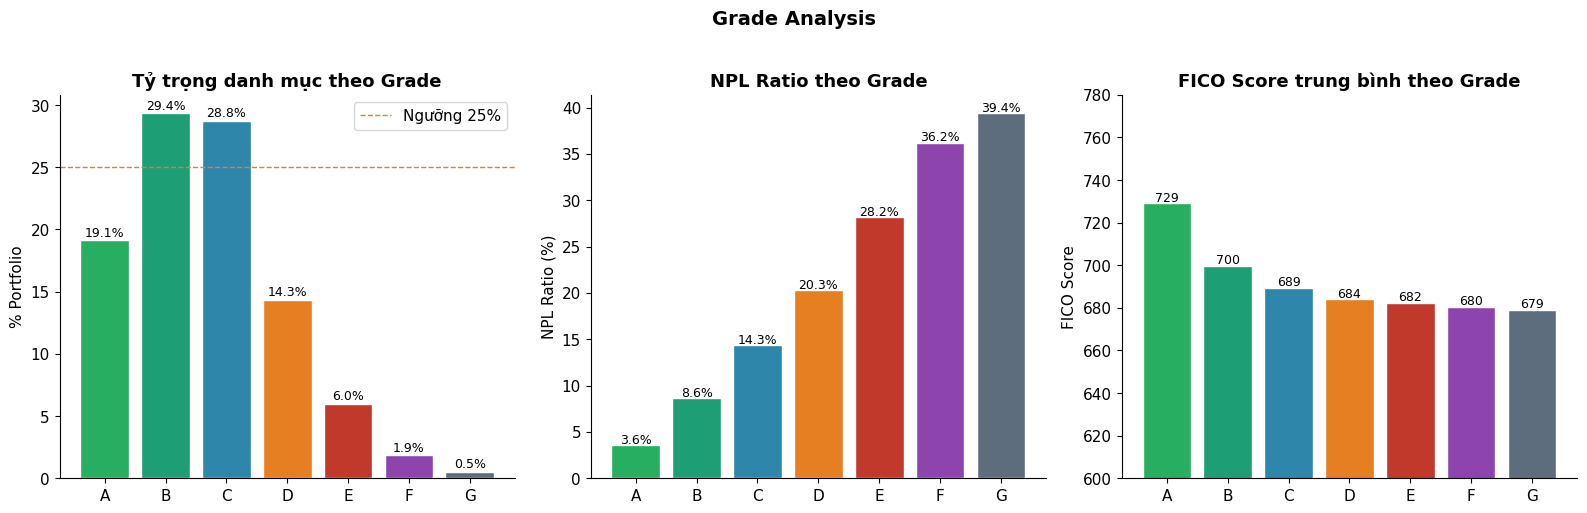

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Portfolio % theo grade
colors_grade = [COLORS["green"],COLORS["teal"],COLORS["blue"],
                COLORS["amber"],COLORS["red"],COLORS["purple"],COLORS["gray"]]
axes[0].bar(df_grade["grade"], df_grade["pct_portfolio"],
            color=colors_grade[:len(df_grade)], edgecolor="white")
axes[0].set_title("Tỷ trọng danh mục theo Grade")
axes[0].set_ylabel("% Portfolio")
axes[0].axhline(25, color=COLORS["amber"], linestyle="--", linewidth=1, label="Ngưỡng 25%")
axes[0].legend()
for i, (g, v) in enumerate(zip(df_grade["grade"], df_grade["pct_portfolio"])):
    axes[0].text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=9)

# Chart 2: NPL ratio theo grade
axes[1].bar(df_grade["grade"], df_grade["npl_ratio_pct"],
            color=colors_grade[:len(df_grade)], edgecolor="white")
axes[1].set_title("NPL Ratio theo Grade")
axes[1].set_ylabel("NPL Ratio (%)")
for i, (g, v) in enumerate(zip(df_grade["grade"], df_grade["npl_ratio_pct"])):
    axes[1].text(i, v+0.2, f"{v:.1f}%", ha="center", fontsize=9)

# Chart 3: FICO trung bình theo grade
axes[2].bar(df_grade["grade"], df_grade["avg_fico"],
            color=colors_grade[:len(df_grade)], edgecolor="white")
axes[2].set_title("FICO Score trung bình theo Grade")
axes[2].set_ylabel("FICO Score")
axes[2].set_ylim([600, 780])
for i, (g, v) in enumerate(zip(df_grade["grade"], df_grade["avg_fico"])):
    axes[2].text(i, v+1, f"{v:.0f}", ha="center", fontsize=9)

plt.suptitle("Grade Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/m1_grade_mix.png", dpi=150, bbox_inches="tight")
plt.show()


## 1.3 — Purpose Mix

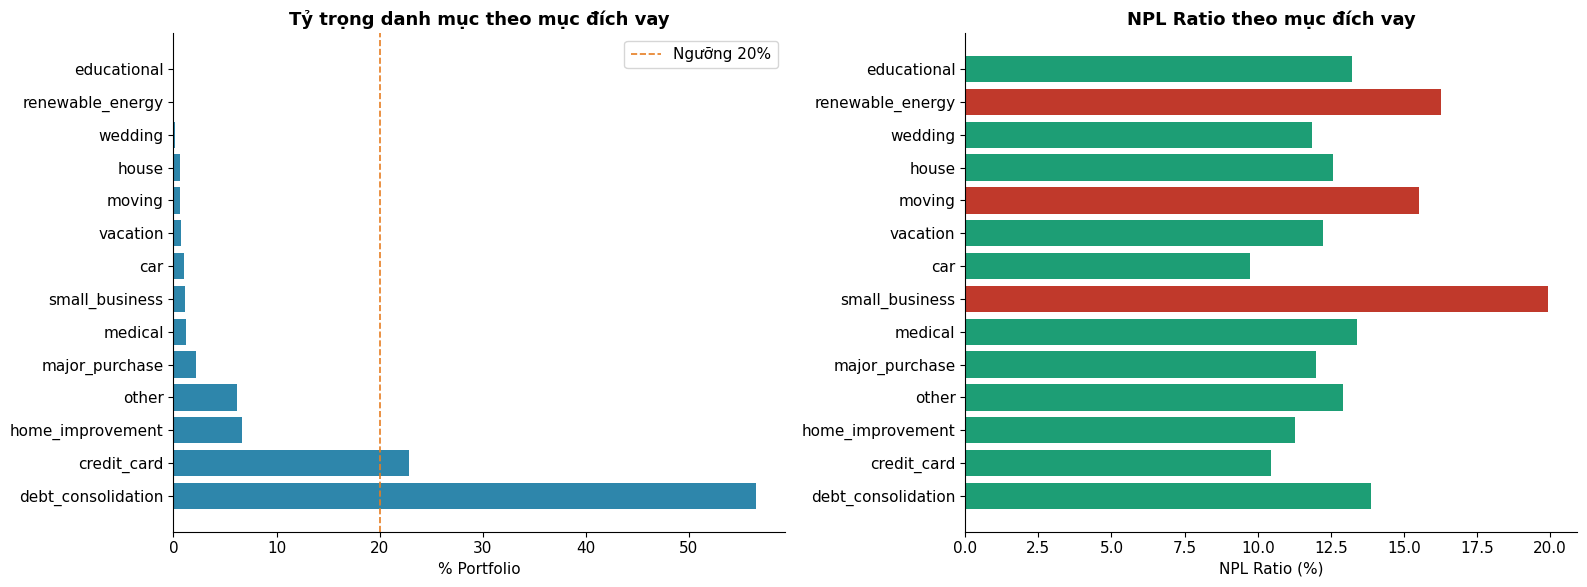

           purpose  loan_count  pct_portfolio  avg_int_rate  npl_ratio_pct          flag
debt_consolidation     1277877          56.53         13.52          13.89    ALERT_BOTH
       credit_card      516971          22.87         11.70          10.45 CONCENTRATION
  home_improvement      150457           6.66         12.62          11.26            OK
             other      139440           6.17         14.24          12.90   CREDIT_RISK
    major_purchase       50445           2.23         12.76          11.98            OK
           medical       27488           1.22         13.63          13.40   CREDIT_RISK
    small_business       24689           1.09         15.26          19.92   CREDIT_RISK
               car       24013           1.06         12.18           9.73            OK
          vacation       15525           0.69         13.45          12.23   CREDIT_RISK
            moving       15403           0.68         14.74          15.53   CREDIT_RISK
             house   

In [7]:
df_purpose = conn.execute("""
    SELECT
        purpose,
        COUNT(*)                                              AS loan_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2)    AS pct_portfolio,
        ROUND(AVG(int_rate), 2)                               AS avg_int_rate,
        ROUND(100.0 * SUM(CASE WHEN debt_group >= 3
            THEN 1 ELSE 0 END) / COUNT(*), 2)               AS npl_ratio_pct,
        -- FIX: Tách 2 chiều — concentration (> 20% portfolio) VÀ credit quality (NPL > 12%)
        CASE WHEN 100.0 * COUNT(*) / SUM(COUNT(*)) OVER() > 20
              AND 100.0 * SUM(CASE WHEN debt_group>=3 THEN 1 ELSE 0 END)/COUNT(*) > 12
             THEN 'ALERT_BOTH'
             WHEN 100.0 * COUNT(*) / SUM(COUNT(*)) OVER() > 20
             THEN 'CONCENTRATION'
             WHEN 100.0 * SUM(CASE WHEN debt_group>=3 THEN 1 ELSE 0 END)/COUNT(*) > 12
             THEN 'CREDIT_RISK'
             ELSE 'OK'
        END                                                  AS flag
    FROM pg.accepted_loans
    WHERE purpose IS NOT NULL
    GROUP BY purpose ORDER BY loan_count DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar: % portfolio
colors_p = [COLORS["red"] if f=="ALERT" else COLORS["blue"] for f in df_purpose["flag"]]
axes[0].barh(df_purpose["purpose"], df_purpose["pct_portfolio"], color=colors_p)
axes[0].set_title("Tỷ trọng danh mục theo mục đích vay")
axes[0].set_xlabel("% Portfolio")
axes[0].axvline(20, color=COLORS["amber"], linestyle="--", linewidth=1.2, label="Ngưỡng 20%")
axes[0].legend()

# NPL theo purpose
axes[1].barh(df_purpose["purpose"], df_purpose["npl_ratio_pct"],
             color=[COLORS["red"] if v>15 else COLORS["teal"]
                    for v in df_purpose["npl_ratio_pct"]])
axes[1].set_title("NPL Ratio theo mục đích vay")
axes[1].set_xlabel("NPL Ratio (%)")

plt.tight_layout()
plt.savefig("results/m1_purpose_mix.png", dpi=150, bbox_inches="tight")
plt.show()
print(df_purpose.to_string(index=False))